In [20]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [2]:
BASE_DIR = Path("..")

RAW_DATA_DIR = BASE_DIR / "data" / "raw"
PROCESSED_DATA_DIR = BASE_DIR / "data" / "processed"

new_data_path = RAW_DATA_DIR / "predictive_maintenance.csv"

PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
df = pd.read_csv(new_data_path)

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (10000, 10)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure


In [4]:
df_clean = df.copy()

In [6]:
df_clean.columns.tolist()

['UDI',
 'Product ID',
 'Type',
 'Air temperature [K]',
 'Process temperature [K]',
 'Rotational speed [rpm]',
 'Torque [Nm]',
 'Tool wear [min]',
 'Target',
 'Failure Type']

In [7]:
df_clean.dtypes

UDI                          int64
Product ID                  object
Type                        object
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Target                       int64
Failure Type                object
dtype: object

In [8]:
missing = df_clean.isnull().sum()

missing_percentage = (
    df_clean.isnull().mean() * 100
)

missing_report = pd.DataFrame({
    "missing_count": missing,
    "missing_percentage": missing_percentage
})

missing_report.sort_values(
    "missing_percentage",
    ascending=False
)

,missing_count,missing_percentage
UDI,0,0.0
Product ID,0,0.0
Type,0,0.0
Air temperature [K],0,0.0
Process temperature [K],0,0.0
Rotational speed [rpm],0,0.0
Torque [Nm],0,0.0
Tool wear [min],0,0.0
Target,0,0.0
Failure Type,0,0.0


In [9]:
duplicate_count = df_clean.duplicated().sum()

print(f"Duplicate rows: {duplicate_count}")

Duplicate rows: 0


In [10]:
print(f"Shape after removing duplicates: {df_clean.shape}")

Shape after removing duplicates: (10000, 10)


In [12]:
df_clean["Target"].value_counts()

Target
0    9661
1     339
Name: count, dtype: int64

In [13]:
df_clean["Target"].value_counts(normalize=True) * 100

Target
0    96.61
1     3.39
Name: proportion, dtype: float64

In [14]:
df_clean["Failure Type"].value_counts()

Failure Type
No Failure                  9652
Heat Dissipation Failure     112
Power Failure                 95
Overstrain Failure            78
Tool Wear Failure             45
Random Failures               18
Name: count, dtype: int64

In [15]:
df_clean["Failure Type"].value_counts(normalize=True) * 100

Failure Type
No Failure                  96.52
Heat Dissipation Failure     1.12
Power Failure                0.95
Overstrain Failure           0.78
Tool Wear Failure            0.45
Random Failures              0.18
Name: proportion, dtype: float64

In [16]:
numeric_columns = df_clean.select_dtypes(
    include=np.number
).columns

df_clean[numeric_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
UDI,10000.0,5000.50000,2886.895680,1.0,2500.75,5000.5,7500.25,10000.0
Air temperature [K],10000.0,300.00493,2.000259,295.3,298.30,300.1,301.50,304.5
Process temperature [K],10000.0,310.00556,1.483734,305.7,308.80,310.1,311.10,313.8
Rotational speed [rpm],10000.0,1538.77610,179.284096,1168.0,1423.00,1503.0,1612.00,2886.0
Torque [Nm],10000.0,39.98691,9.968934,3.8,33.20,40.1,46.80,76.6
Tool wear [min],10000.0,107.95100,63.654147,0.0,53.00,108.0,162.00,253.0
Target,10000.0,0.03390,0.180981,0.0,0.00,0.0,0.00,1.0


In [18]:
for col in numeric_columns:
    print(f"\n{col}")
    print("Min:", df_clean[col].min())
    print("Max:", df_clean[col].max())


UDI
Min: 1
Max: 10000

Air temperature [K]
Min: 295.3
Max: 304.5

Process temperature [K]
Min: 305.7
Max: 313.8

Rotational speed [rpm]
Min: 1168
Max: 2886

Torque [Nm]
Min: 3.8
Max: 76.6

Tool wear [min]
Min: 0
Max: 253

Target
Min: 0
Max: 1


In [19]:
correlation = df_clean[numeric_columns].corr()

correlation

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target
UDI,1.000000,0.117428,0.324428,-0.006615,0.003207,-0.010702,-0.022892
Air temperature [K],0.117428,1.000000,0.876107,0.022670,-0.013778,0.013853,0.082556
Process temperature [K],0.324428,0.876107,1.000000,0.019277,-0.014061,0.013488,0.035946
Rotational speed [rpm],-0.006615,0.022670,0.019277,1.000000,-0.875027,0.000223,-0.044188
Torque [Nm],0.003207,-0.013778,-0.014061,-0.875027,1.000000,-0.003093,0.191321
Tool wear [min],-0.010702,0.013853,0.013488,0.000223,-0.003093,1.000000,0.105448
Target,-0.022892,0.082556,0.035946,-0.044188,0.191321,0.105448,1.000000


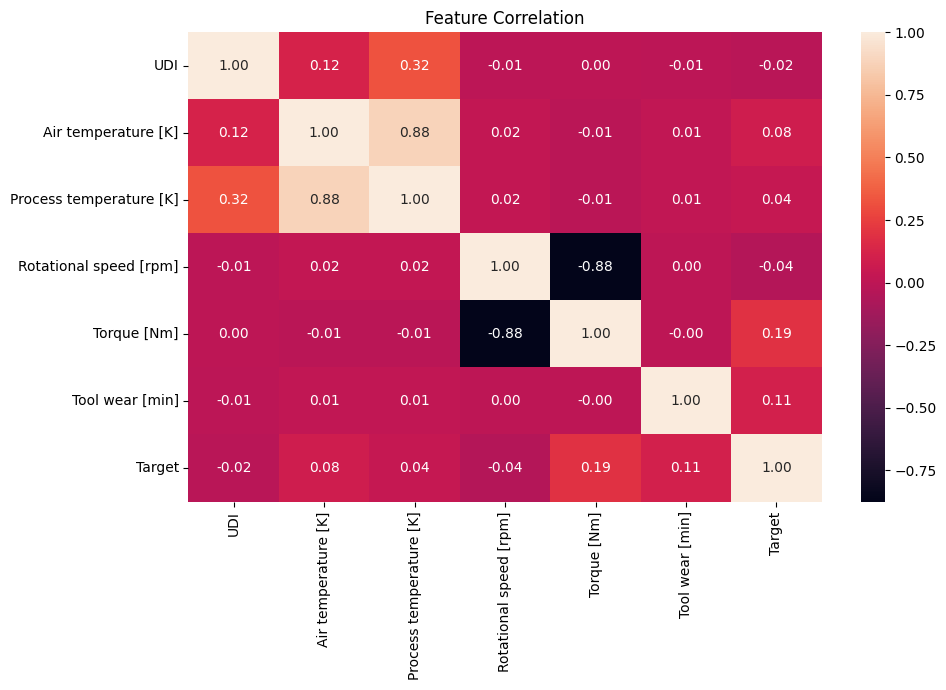

In [21]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f"
)

plt.title("Feature Correlation")
plt.tight_layout()
plt.show()

In [22]:
feature_columns = [
    "Type",
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

In [23]:
target_column = "Target"

In [24]:
failure_type_target = "Failure Type"

In [25]:
failure_df = df_clean[
    df_clean["Target"] == 1
].copy()

In [26]:
clean_path = PROCESSED_DATA_DIR / "predictive_maintenance_clean.csv"

df_clean.to_csv(
    clean_path,
    index=False
)

print(f"Saved cleaned dataset to: {clean_path}")

Saved cleaned dataset to: ..\data\processed\predictive_maintenance_clean.csv
